# mexari - Spatio-Temporal Forecasting with PyG
Forecast municipal ARI mortality with a sliding-window graph neural network built only with PyTorch and PyTorch Geometric.

This notebook follows the style of the existing notebooks in `notebooks/`:
- build the graph with `mexari.build_graph()`
- get node histories with `mexari.get_node_feature_matrix()`
- get the spatial connectivity with `mexari.get_edge_index()`

From there, we create sliding windows over the node-level weekly mortality signal and train a PyG forecaster to predict `N` weeks ahead.


## 1 · Optional environment setup

Uncomment the next cell if your environment is still missing PyTorch or PyTorch Geometric.


In [1]:
# %pip install -U pandas matplotlib torch
# %pip install torch-geometric


## 2 · Imports and experiment configuration


In [2]:
from copy import deepcopy
from pathlib import Path
import importlib
import sys

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

try:
    from torch_geometric.data import Batch, Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv
except ImportError as exc:
    raise ImportError(
        "This notebook requires `torch_geometric`. Install PyTorch and PyG before running it."
    ) from exc

import mexari as mx
mx = importlib.reload(mx)

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

WINDOW_WEEKS = 26
HORIZON_WEEKS = 4
STRIDE = 1
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEMPORAL_GAP = 4
BATCH_SIZE = 4
MAX_EPOCHS = 250
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE = 50
LR_PATIENCE = 6

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

plt.style.use("seaborn-v0_8-whitegrid")

print(f"mexari version : {mx.__version__}")
print(f"Bundled CSV    : {mx.DEFAULT_CSV}")
print(f"Torch version  : {torch.__version__}")
print(f"Device         : {device}")
print(
    "Forecast setup : "
    f"window={WINDOW_WEEKS}, horizon={HORIZON_WEEKS}, stride={STRIDE}, gap={TEMPORAL_GAP}"
)

mexari version : 0.1.0
Bundled CSV    : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/mortality_rates.csv
Torch version  : 2.11.0+cu128
Device         : cuda
Forecast setup : window=26, horizon=4, stride=1, gap=4


/home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 · Build the graph exactly like the other repo notebooks

This uses the same local GeoJSON pattern already present in `graph_visualization.ipynb`, `node_classification.ipynb`, and `edge_label_classification.ipynb`.


In [3]:
geojson_path = Path("../Data/mexico.geojson")

if not geojson_path.exists():
    raise FileNotFoundError(
        f"Set `geojson_path` to a local GeoJSON file before running the notebook: {geojson_path}"
    )

G = mx.build_graph(geojson_path=geojson_path)

print(f"Nodes   : {G.number_of_nodes()}")
print(f"Edges   : {G.number_of_edges()}")
print(f"Dates   : {len(G.graph['dates'])}")
print(f"Density : {nx.density(G):.5f}")

sample = G.nodes[0]
print("\nSample node attributes:")
for key, value in sample.items():
    if key in ("mortality", "features"):
        print(f"  {key}: {type(value).__name__} with {len(value)} entries")
    else:
        print(f"  {key}: {value}")


Nodes   : 2475
Edges   : 7246
Dates   : 1148
Density : 0.00237

Sample node attributes:
  municipality: San José de Gracia
  state: Aguascalientes
  longitude: -102.52583871928235
  latitude: 22.146634606582133
  mortality: dict with 1148 entries
  features: ndarray with 1148 entries


## 4 · Build the PyG-ready signal tensors from `mexari`

Instead of re-reading the bundled CSV, we reuse the node feature matrix already exposed by `mexari`. The returned matrix has shape `(nodes, weeks)`, so we transpose it into `(weeks, nodes)` before building sliding windows.


In [4]:
X_np, node_order = mx.get_node_feature_matrix(G)
edge_index = torch.tensor(mx.get_edge_index(G, node_order), dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float32)

time_signal = torch.tensor(X_np.T, dtype=torch.float32)
week_labels = pd.Index(G.graph["dates"], name="epiweek")
mortality_df = pd.DataFrame(time_signal.numpy(), index=week_labels, columns=node_order)

node_frame = (
    pd.DataFrame(
        [
            {
                "node": node,
                "municipality": G.nodes[node]["municipality"],
                "state": G.nodes[node]["state"],
                "longitude": G.nodes[node]["longitude"],
                "latitude": G.nodes[node]["latitude"],
            }
            for node in node_order
        ]
    )
    .set_index("node")
)

NUM_NODES = len(node_order)
NUM_WEEKS = len(week_labels)

print(f"Node feature matrix X : {X_np.shape}  (nodes x weeks)")
print(f"Time signal           : {tuple(time_signal.shape)}  (weeks x nodes)")
print(f"Edge index            : {tuple(edge_index.shape)}  (2 x directed_edges)")
print(f"Node metadata frame   : {node_frame.shape}")

mortality_df.iloc[:5, :5]


Node feature matrix X : (2475, 1148)  (nodes x weeks)
Time signal           : (1148, 2475)  (weeks x nodes)
Edge index            : (2, 14492)  (2 x directed_edges)
Node metadata frame   : (2475, 4)


,0,1,2,3,4
epiweek,,,,,
2003/01,0.0,4.484707,0.0,0.0,0.530942
2003/02,0.0,0.000000,0.0,0.0,0.955696
2003/03,0.0,0.000000,0.0,0.0,0.318565
2003/04,0.0,0.000000,0.0,0.0,0.637131
2003/05,0.0,0.000000,0.0,0.0,0.637131


## 5 · Quick sanity checks on the weekly signal


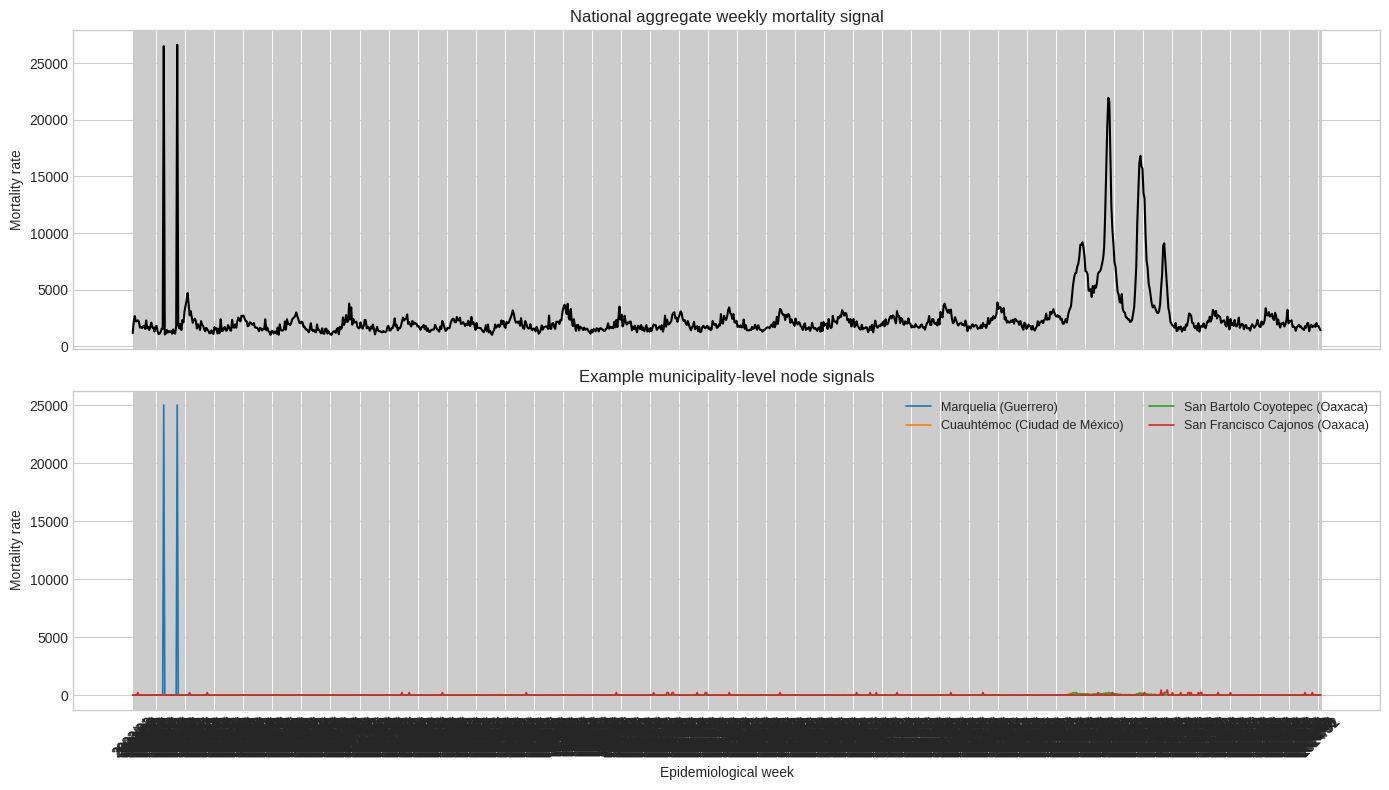

In [5]:
national_series = mortality_df.sum(axis=1)
top_nodes = mortality_df.mean(axis=0).sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(national_series.index, national_series.values, color="black", linewidth=1.5)
axes[0].set_title("National aggregate weekly mortality signal")
axes[0].set_ylabel("Mortality rate")

for node in top_nodes:
    label = f"{node_frame.loc[node, 'municipality']} ({node_frame.loc[node, 'state']})"
    axes[1].plot(mortality_df.index, mortality_df[node], linewidth=1.2, label=label)

axes[1].set_title("Example municipality-level node signals")
axes[1].set_ylabel("Mortality rate")
axes[1].set_xlabel("Epidemiological week")
axes[1].legend(loc="upper right", ncols=2, fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6 · Create sliding-window graph samples with PyG

Each sample is a `torch_geometric.data.Data` object:
- `x`: one graph snapshot containing `WINDOW_WEEKS` of node history as features
- `y`: the next `HORIZON_WEEKS` values to forecast for every municipality

The spatial graph stays fixed; only the time window changes from sample to sample.


In [6]:
class MunicipalityWindowDataset(Dataset):
    def __init__(self, time_signal, edge_index, edge_weight, window, horizon, starts):
        self.time_signal = time_signal
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.window = window
        self.horizon = horizon
        self.starts = list(starts)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        start = self.starts[idx]
        history = self.time_signal[start : start + self.window].T.contiguous()
        target = self.time_signal[
            start + self.window : start + self.window + self.horizon
        ].T.contiguous()

        data = Data(
            x=history,
            y=target,
            edge_index=self.edge_index,
            edge_weight=self.edge_weight,
        )
        data.window_start = torch.tensor([start], dtype=torch.long)
        data.target_start = torch.tensor([start + self.window], dtype=torch.long)
        return data


split = mx.make_temporal_split(
    num_weeks=NUM_WEEKS,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    gap=TEMPORAL_GAP,
)

train_starts = mx.region_window_starts(
    region_start=0,
    region_end=split.train_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
)
val_starts = mx.region_window_starts(
    region_start=split.val_start,
    region_end=split.val_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
 )
test_starts = mx.region_window_starts(
    region_start=split.test_start,
    region_end=split.test_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
 )

if not train_starts or not val_starts or not test_starts:
    raise ValueError(
        "Current split parameters do not leave enough room for train/val/test windows. "
        "Reduce `WINDOW_WEEKS`, reduce `TEMPORAL_GAP`, or adjust the split ratios."
    )

scale_mean, scale_std = mx.train_scaler_from_region(time_signal, train_end=split.train_end)
scaled_time_signal = mx.scale_time_signal(time_signal, scale_mean, scale_std)

train_dataset = MunicipalityWindowDataset(
    time_signal=scaled_time_signal,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=train_starts,
 )
val_dataset = MunicipalityWindowDataset(
    time_signal=scaled_time_signal,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=val_starts,
 )
test_dataset = MunicipalityWindowDataset(
    time_signal=scaled_time_signal,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=test_starts,
 )

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample = train_dataset[0]

split_frame = pd.DataFrame(
    [
        {
            "split": "train",
            "history_start": week_labels[train_starts[0]],
            "history_end": week_labels[train_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[train_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(train_starts),
        },
        {
            "split": "validation",
            "history_start": week_labels[val_starts[0]],
            "history_end": week_labels[val_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[val_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(val_starts),
        },
        {
            "split": "test",
            "history_start": week_labels[test_starts[0]],
            "history_end": week_labels[test_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[test_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(test_starts),
        },
    ]
)

print(f"Train weeks      : 0 to {split.train_end - 1}")
print(f"Validation weeks : {split.val_start} to {split.val_end - 1}")
print(f"Test weeks       : {split.test_start} to {split.test_end - 1}")
print(f"Train windows    : {len(train_dataset)}")
print(f"Val windows      : {len(val_dataset)}")
print(f"Test windows     : {len(test_dataset)}")
print(f"Sample x         : {tuple(sample.x.shape)}  (nodes x window)")
print(f"Sample y         : {tuple(sample.y.shape)}  (nodes x horizon)")

split_frame

Train weeks      : 0 to 917
Validation weeks : 922 to 1035
Test weeks       : 1040 to 1147
Train windows    : 889
Val windows      : 85
Test windows     : 79
Sample x         : (2475, 26)  (nodes x window)
Sample y         : (2475, 4)  (nodes x horizon)


,split,history_start,history_end,target_end,n_windows
0,train,2003/01,2020/27,2020/31,889
1,validation,2020/36,2022/40,2022/44,85
2,test,2022/49,2024/48,2024/52,79


## 7 · Define a pure PyG forecaster

The model uses:
- a GRU to encode the temporal window at each municipality
- `GCNConv` layers to propagate information over the municipal adjacency graph
- a small MLP decoder to predict the next `HORIZON_WEEKS`

Because every sample uses the same fixed graph and node order, we can safely reuse a learnable node embedding indexed by the municipality position inside each graph.


In [7]:
class PyGMortalityForecaster(nn.Module):
    def __init__(
        self,
        num_nodes,
        horizon,
        temporal_channels=16,
        rnn_hidden=32,
        spatial_hidden=64,
        node_emb_dim=12,
        dropout=0.25,
    ):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon = horizon
        self.dropout = dropout

        self.temporal_conv = nn.Sequential(
            nn.Conv1d(1, temporal_channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(temporal_channels, temporal_channels, kernel_size=5, padding=2),
            nn.GELU(),
        )
        self.temporal_encoder = nn.GRU(
            input_size=temporal_channels,
            hidden_size=rnn_hidden,
            num_layers=2,
            dropout=dropout,
            batch_first=True,
            bidirectional=True,
        )
        self.node_embedding = nn.Embedding(num_nodes, node_emb_dim)
        self.input_projection = nn.Linear(rnn_hidden * 2 + node_emb_dim, spatial_hidden)
        self.sage1 = SAGEConv(spatial_hidden, spatial_hidden)
        self.sage2 = SAGEConv(spatial_hidden, spatial_hidden)
        self.norm1 = nn.LayerNorm(spatial_hidden)
        self.norm2 = nn.LayerNorm(spatial_hidden)
        self.decoder = nn.Sequential(
            nn.Linear(spatial_hidden, spatial_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(spatial_hidden, horizon),
        )

    def forward(self, data):
        x_seq = data.x.unsqueeze(1)
        x_seq = self.temporal_conv(x_seq).transpose(1, 2).contiguous()

        _, hidden = self.temporal_encoder(x_seq)
        h = torch.cat([hidden[-2], hidden[-1]], dim=-1)

        local_node_ids = torch.arange(h.size(0), device=h.device) % self.num_nodes
        node_emb = self.node_embedding(local_node_ids)

        z = torch.cat([h, node_emb], dim=-1)
        z = self.input_projection(z)

        residual = z
        z = self.sage1(z, data.edge_index)
        z = F.gelu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = self.norm1(z + residual)

        residual = z
        z = self.sage2(z, data.edge_index)
        z = F.gelu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = self.norm2(z + residual)

        return self.decoder(z)


model = PyGMortalityForecaster(
    num_nodes=NUM_NODES,
    horizon=HORIZON_WEEKS,
    temporal_channels=16,
    rnn_hidden=32,
    spatial_hidden=64,
    node_emb_dim=12,
    dropout=0.25,
).to(device)

n_params = sum(param.numel() for param in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

PyGMortalityForecaster(
  (temporal_conv): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GELU(approximate='none')
    (2): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): GELU(approximate='none')
  )
  (temporal_encoder): GRU(16, 32, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (node_embedding): Embedding(2475, 12)
  (input_projection): Linear(in_features=76, out_features=64, bias=True)
  (sage1): SAGEConv(64, 64, aggr=mean)
  (sage2): SAGEConv(64, 64, aggr=mean)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable parameters: 85,592


## 8 · Train the forecaster

We optimize a smooth L1 loss on the scaled target and report MAE after restoring the original mortality scale.


In [8]:
mean_per_node = scale_mean.squeeze(0).to(device)
std_per_node = scale_std.squeeze(0).to(device)

if device.type == "cuda":
    torch.cuda.empty_cache()


def restore_scale(values):
    node_ids = torch.arange(values.size(0), device=values.device) % NUM_NODES
    mean = mean_per_node[node_ids].unsqueeze(-1)
    std = std_per_node[node_ids].unsqueeze(-1)
    return values * std + mean


criterion = nn.SmoothL1Loss(beta=0.25)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-5,
)


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_abs_error = 0.0
    total_values = 0

    for batch in loader:
        batch = batch.to(device)

        with torch.set_grad_enabled(training):
            pred = model(batch)
            loss = criterion(pred, batch.y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        pred_orig = restore_scale(pred.detach())
        target_orig = restore_scale(batch.y.detach())

        total_loss += float(loss.detach()) * batch.y.numel()
        total_abs_error += torch.abs(pred_orig - target_orig).sum().item()
        total_values += batch.y.numel()

    return total_loss / total_values, total_abs_error / total_values


def predict_loader(loader):
    predictions = []
    targets = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            predictions.append(restore_scale(pred).cpu())
            targets.append(restore_scale(batch.y).cpu())

    return torch.cat(predictions, dim=0), torch.cat(targets, dim=0)


history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": [],
    "lr": [],
}

best_state = deepcopy(model.state_dict())
best_val_mae = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_mae = run_epoch(train_loader, training=True)
    val_loss, val_mae = run_epoch(val_loader, training=False)
    scheduler.step(val_mae)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"train_mae={train_mae:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.5f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch:03d}")
        break

model.load_state_dict(best_state)
print(f"Best validation MAE: {best_val_mae:.4f} at epoch {best_epoch}")

Epoch 001 | train_loss=0.3079 | train_mae=1.0368 | val_loss=3391.3649 | val_mae=1.7839 | lr=0.00100
Epoch 010 | train_loss=0.2888 | train_mae=0.8595 | val_loss=3391.2875 | val_mae=1.6672 | lr=0.00100
Epoch 020 | train_loss=0.2871 | train_mae=0.8490 | val_loss=3391.3293 | val_mae=1.7503 | lr=0.00050
Epoch 030 | train_loss=0.2865 | train_mae=0.8468 | val_loss=3391.3146 | val_mae=1.7136 | lr=0.00025
Epoch 040 | train_loss=0.2862 | train_mae=0.8451 | val_loss=3391.3243 | val_mae=1.7279 | lr=0.00006
Epoch 050 | train_loss=0.2861 | train_mae=0.8451 | val_loss=3391.3366 | val_mae=1.7546 | lr=0.00003
Epoch 060 | train_loss=0.2861 | train_mae=0.8451 | val_loss=3391.3334 | val_mae=1.7453 | lr=0.00001
Early stopping at epoch 061
Best validation MAE: 1.6374 at epoch 11


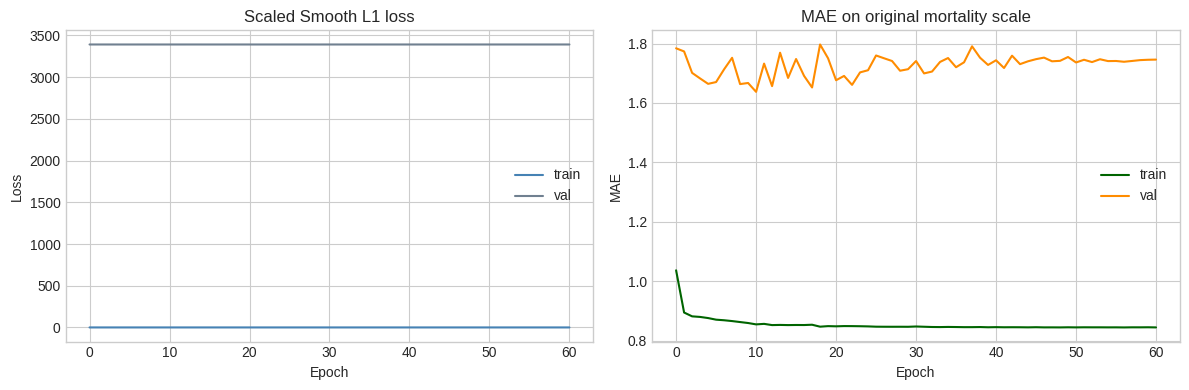

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train", color="steelblue")
axes[0].plot(history["val_loss"], label="val", color="slategray")
axes[0].set_title("Scaled Smooth L1 loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_mae"], label="train", color="darkgreen")
axes[1].plot(history["val_mae"], label="val", color="darkorange")
axes[1].set_title("MAE on original mortality scale")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9 · Evaluate on held-out windows and inspect one `N`-weeks-ahead forecast


Test loss : 803.3659
Test MAE  : 0.7875
Horizon-wise test MAE:
  t+1: 0.7895
  t+2: 0.7897
  t+3: 0.7869
  t+4: 0.7840


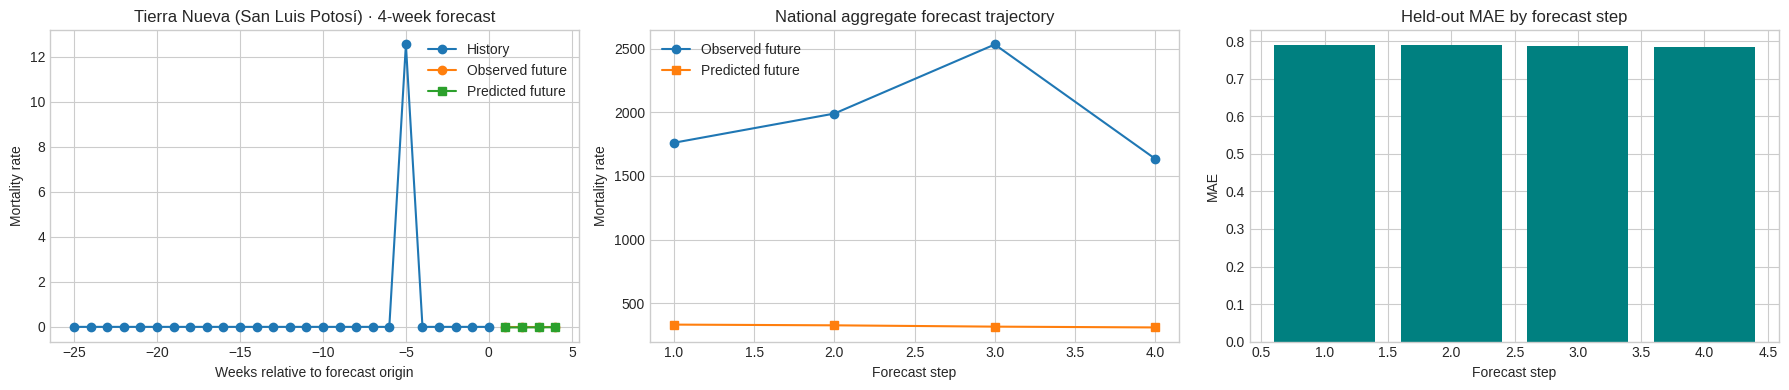

In [10]:
test_loss, test_mae = run_epoch(test_loader, training=False)
test_pred, test_target = predict_loader(test_loader)
horizon_mae = torch.abs(test_pred - test_target).mean(dim=0)

print(f"Test loss : {test_loss:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print("Horizon-wise test MAE:")
for step, value in enumerate(horizon_mae.tolist(), start=1):
    print(f"  t+{step}: {value:.4f}")

example = test_dataset[0]
example_batch = Batch.from_data_list([example]).to(device)

model.eval()
with torch.no_grad():
    pred_scaled = model(example_batch)

history_orig = restore_scale(example_batch.x).cpu()
target_orig = restore_scale(example_batch.y).cpu()
pred_orig = restore_scale(pred_scaled).cpu()

example_node = mortality_df.mean(axis=0).sort_values(ascending=True).index[1858]
example_label = (
    f"{node_frame.loc[example_node, 'municipality']} "
    f"({node_frame.loc[example_node, 'state']})"
 )

history_axis = np.arange(-WINDOW_WEEKS + 1, 1)
forecast_axis = np.arange(1, HORIZON_WEEKS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(
    history_axis,
    history_orig[example_node].numpy(),
    marker="o",
    linewidth=1.5,
    label="History",
)
axes[0].plot(
    forecast_axis,
    target_orig[example_node].numpy(),
    marker="o",
    linewidth=1.5,
    label="Observed future",
)
axes[0].plot(
    forecast_axis,
    pred_orig[example_node].numpy(),
    marker="s",
    linewidth=1.5,
    label="Predicted future",
)
axes[0].set_title(f"{example_label} · {HORIZON_WEEKS}-week forecast")
axes[0].set_xlabel("Weeks relative to forecast origin")
axes[0].set_ylabel("Mortality rate")
axes[0].legend()

national_true = target_orig.sum(dim=0).numpy()
national_pred = pred_orig.sum(dim=0).numpy()

axes[1].plot(
    forecast_axis,
    national_true,
    marker="o",
    linewidth=1.5,
    label="Observed future",
)
axes[1].plot(
    forecast_axis,
    national_pred,
    marker="s",
    linewidth=1.5,
    label="Predicted future",
)
axes[1].set_title("National aggregate forecast trajectory")
axes[1].set_xlabel("Forecast step")
axes[1].set_ylabel("Mortality rate")
axes[1].legend()

axes[2].bar(forecast_axis, horizon_mae.numpy(), color="teal")
axes[2].set_title("Held-out MAE by forecast step")
axes[2].set_xlabel("Forecast step")
axes[2].set_ylabel("MAE")

plt.tight_layout()
plt.show()

In [11]:
node_error_sum = torch.zeros(NUM_NODES)
node_error_count = torch.zeros(NUM_NODES)

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        abs_error = torch.abs(restore_scale(pred) - restore_scale(batch.y))
        per_node_error = abs_error.mean(dim=1).cpu()
        node_ids = torch.arange(per_node_error.size(0)) % NUM_NODES
        node_error_sum.index_add_(0, node_ids, per_node_error)
        node_error_count.index_add_(0, node_ids, torch.ones_like(per_node_error))

node_test_mae = node_error_sum / node_error_count.clamp_min(1.0)

error_frame = node_frame.assign(
    mean_mortality=mortality_df.mean(axis=0).values,
    test_mae=node_test_mae.numpy(),
).sort_values("test_mae", ascending=False)

error_frame.head(10)

,municipality,state,longitude,latitude,mean_mortality,test_mae
node,,,,,,
1157,Santa Magdalena Jicotlán,Oaxaca,-97.481790,17.806607,2.150815,16.042225
1009,Melchor Ocampo,Nuevo León,-99.493516,26.048931,2.022000,11.568477
1225,San Bartolo Coyotepec,Oaxaca,-96.695615,16.941142,13.092971,8.530167
384,Marquelia,Guerrero,-98.745024,16.638964,44.421928,7.685987
1276,San Jerónimo Tecóatl,Oaxaca,-96.929032,18.153798,4.584632,7.272224
1094,San Pedro Topiltepec,Oaxaca,-97.357436,17.455246,1.401201,6.878285
1112,San Pedro y San Pablo Ayutla,Oaxaca,-96.134983,17.021742,3.383420,5.972366
1253,San Francisco Cajonos,Oaxaca,-96.264646,17.180862,8.884631,5.822827
934,Tetecala,Morelos,-99.412394,18.692736,3.510852,5.777860


Rolling-origin summary vs current held-out metrics


,metric,value
0,Current held-out test MAE,0.7875
1,Rolling-origin mean MAE,0.7899
2,Rolling-origin MAE std,0.1241
3,Rolling-origin MAE min,0.6495
4,Rolling-origin MAE max,1.0308
5,Mean delta vs current test MAE,0.0024


Per-origin MAE (lower is better)


,forecast_origin,origin_mae,t+1,t+2,t+3,t+4
0,2023/23,0.7827,0.7051,0.7822,0.9923,0.6511
1,2023/31,0.6847,0.7275,0.7470,0.6221,0.6421
2,2023/40,0.7721,0.6614,0.7267,0.7667,0.9334
3,2023/49,1.0087,0.7764,0.9005,1.3117,1.0460
4,2024/05,1.0308,1.1221,0.9433,0.9011,1.1568
5,2024/14,0.7773,0.7968,0.7851,0.8378,0.6896
6,2024/23,0.7963,0.8607,0.9165,0.6988,0.7089
7,2024/31,0.6944,0.7563,0.6793,0.7073,0.6349
8,2024/40,0.7027,0.8239,0.5364,0.6917,0.7589
9,2024/49,0.6495,0.7118,0.7031,0.6170,0.5662


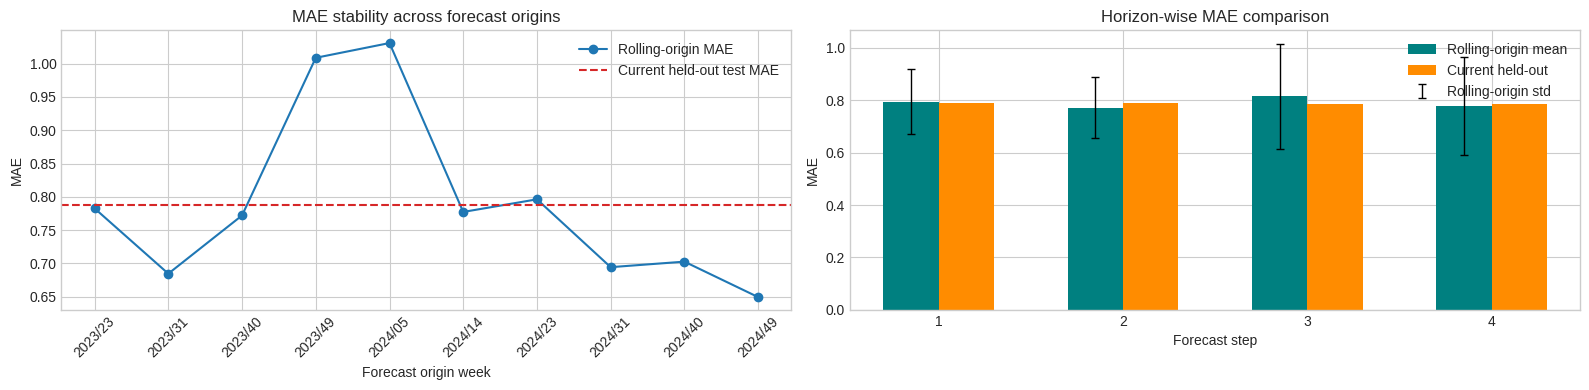

In [12]:
def evaluate_origin(start_idx):
    history = scaled_time_signal[start_idx : start_idx + WINDOW_WEEKS].T.contiguous()
    target = scaled_time_signal[
        start_idx + WINDOW_WEEKS : start_idx + WINDOW_WEEKS + HORIZON_WEEKS
    ].T.contiguous()

    data = Data(
        x=history,
        y=target,
        edge_index=edge_index,
        edge_weight=edge_weight,
    )
    batch = Batch.from_data_list([data]).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(batch)

    pred_orig = restore_scale(pred).cpu()
    target_orig = restore_scale(batch.y).cpu()
    abs_error = torch.abs(pred_orig - target_orig)

    metrics = {
        "origin_start_idx": start_idx,
        "forecast_origin": str(week_labels[start_idx + WINDOW_WEEKS]),
        "origin_mae": abs_error.mean().item(),
    }
    for step in range(HORIZON_WEEKS):
        metrics[f"t+{step + 1}"] = abs_error[:, step].mean().item()
    return metrics


num_backtest_origins = 10
if len(test_starts) <= num_backtest_origins:
    selected_origins = list(test_starts)
else:
    sampled_idx = np.linspace(
        0, len(test_starts) - 1, num=num_backtest_origins, dtype=int
    )
    selected_origins = [test_starts[i] for i in sampled_idx]

rolling_rows = [evaluate_origin(start_idx) for start_idx in selected_origins]
rolling_df = pd.DataFrame(rolling_rows)

horizon_cols = [f"t+{step}" for step in range(1, HORIZON_WEEKS + 1)]
rolling_horizon_mean = rolling_df[horizon_cols].mean(axis=0)
rolling_horizon_std = rolling_df[horizon_cols].std(axis=0, ddof=0)

comparison_frame = pd.DataFrame(
    [
        {
            "metric": "Current held-out test MAE",
            "value": float(test_mae),
        },
        {
            "metric": "Rolling-origin mean MAE",
            "value": float(rolling_df["origin_mae"].mean()),
        },
        {
            "metric": "Rolling-origin MAE std",
            "value": float(rolling_df["origin_mae"].std(ddof=0)),
        },
        {
            "metric": "Rolling-origin MAE min",
            "value": float(rolling_df["origin_mae"].min()),
        },
        {
            "metric": "Rolling-origin MAE max",
            "value": float(rolling_df["origin_mae"].max()),
        },
        {
            "metric": "Mean delta vs current test MAE",
            "value": float(rolling_df["origin_mae"].mean() - test_mae),
        },
    ]
)

print("Rolling-origin summary vs current held-out metrics")
display(comparison_frame.style.format({"value": "{:.4f}"}))

print("Per-origin MAE (lower is better)")
display(
    rolling_df
    .sort_values("origin_start_idx")
    .reset_index(drop=True)[["forecast_origin", "origin_mae"] + horizon_cols]
    .style.format({col: "{:.4f}" for col in ["origin_mae"] + horizon_cols})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(
    rolling_df["forecast_origin"],
    rolling_df["origin_mae"],
    marker="o",
    linewidth=1.5,
    color="tab:blue",
    label="Rolling-origin MAE",
)
axes[0].axhline(
    y=test_mae,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label="Current held-out test MAE",
)
axes[0].set_title("MAE stability across forecast origins")
axes[0].set_xlabel("Forecast origin week")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

x_axis = np.arange(1, HORIZON_WEEKS + 1)
axes[1].bar(
    x_axis - 0.15,
    rolling_horizon_mean.values,
    width=0.30,
    color="teal",
    label="Rolling-origin mean",
)
axes[1].bar(
    x_axis + 0.15,
    horizon_mae.numpy(),
    width=0.30,
    color="darkorange",
    label="Current held-out",
)
axes[1].errorbar(
    x_axis - 0.15,
    rolling_horizon_mean.values,
    yerr=rolling_horizon_std.values,
    fmt="none",
    ecolor="black",
    capsize=3,
    linewidth=1,
    label="Rolling-origin std",
)
axes[1].set_title("Horizon-wise MAE comparison")
axes[1].set_xlabel("Forecast step")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x_axis)
axes[1].legend()

plt.tight_layout()
plt.show()

Backtesting diagnostic summary


,metric,value
0,Current held-out MAE,0.7875
1,Rolling-origin mean MAE,0.7899
2,Difficult-origin threshold (mean + 1 std),0.9140
3,Difficult origins found,2.0000


Difficult forecast-origin weeks


,forecast_origin,origin_mae,origin_level,origin_volatility,level_vs_avg_pct,vol_vs_avg_pct
0,2024/05,1.0308,2654.02,379.66,+32.7%,+35.9%
1,2023/49,1.0087,2609.87,205.29,+30.5%,-26.5%


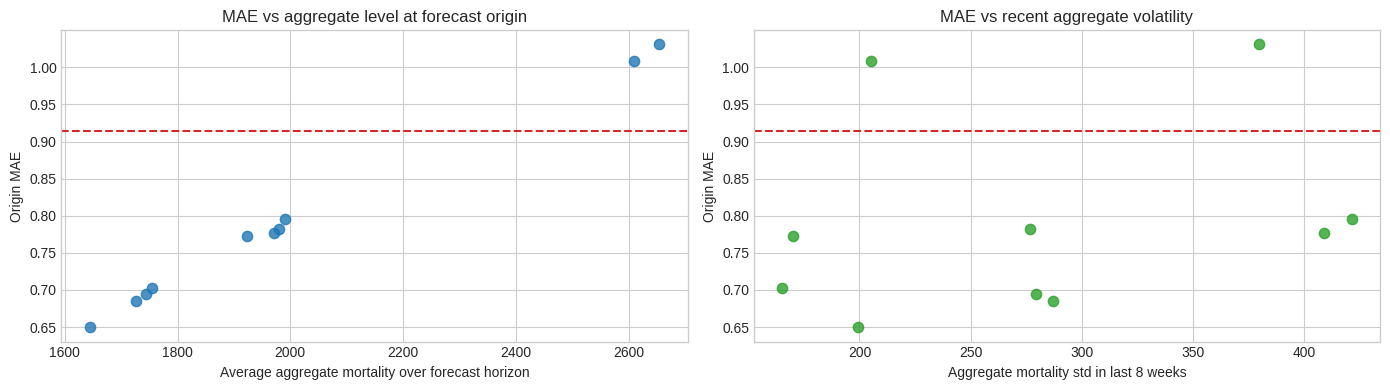

In [13]:
rolling_summary = rolling_df.copy()
rolling_summary["origin_level"] = [
    float(
        mortality_df.iloc[
            start_idx + WINDOW_WEEKS : start_idx + WINDOW_WEEKS + HORIZON_WEEKS
        ].sum(axis=1).mean()
    )
    for start_idx in rolling_summary["origin_start_idx"]
 ]
rolling_summary["origin_volatility"] = [
    float(
        mortality_df.iloc[
            start_idx + WINDOW_WEEKS - 8 : start_idx + WINDOW_WEEKS
        ].sum(axis=1).std(ddof=0)
    )
    for start_idx in rolling_summary["origin_start_idx"]
 ]

threshold = float(
    rolling_summary["origin_mae"].mean() + rolling_summary["origin_mae"].std(ddof=0)
 )
difficult_origins = (
    rolling_summary[rolling_summary["origin_mae"] >= threshold]
    .sort_values("origin_mae", ascending=False)
    .reset_index(drop=True)
 )

overall_level = float(rolling_summary["origin_level"].mean())
overall_volatility = float(rolling_summary["origin_volatility"].mean())

summary_frame = pd.DataFrame(
    [
        {"metric": "Current held-out MAE", "value": float(test_mae)},
        {
            "metric": "Rolling-origin mean MAE",
            "value": float(rolling_summary["origin_mae"].mean()),
        },
        {
            "metric": "Difficult-origin threshold (mean + 1 std)",
            "value": threshold,
        },
        {"metric": "Difficult origins found", "value": float(len(difficult_origins))},
    ]
)

print("Backtesting diagnostic summary")
display(summary_frame.style.format({"value": "{:.4f}"}))

if difficult_origins.empty:
    print(
        "No difficult origins above threshold. The model appears stable across sampled origins."
    )
else:
    difficult_report = difficult_origins[
        [
            "forecast_origin",
            "origin_mae",
            "origin_level",
            "origin_volatility",
        ]
    ].copy()
    difficult_report["level_vs_avg_pct"] = (
        100.0 * (difficult_report["origin_level"] - overall_level) / max(overall_level, 1e-8)
    )
    difficult_report["vol_vs_avg_pct"] = (
        100.0
        * (difficult_report["origin_volatility"] - overall_volatility)
        / max(overall_volatility, 1e-8)
    )

    print("Difficult forecast-origin weeks")
    display(
        difficult_report.style.format(
            {
                "origin_mae": "{:.4f}",
                "origin_level": "{:.2f}",
                "origin_volatility": "{:.2f}",
                "level_vs_avg_pct": "{:+.1f}%",
                "vol_vs_avg_pct": "{:+.1f}%",
            }
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].scatter(
        rolling_summary["origin_level"],
        rolling_summary["origin_mae"],
        s=55,
        alpha=0.8,
        color="tab:blue",
    )
    axes[0].axhline(threshold, color="tab:red", linestyle="--", linewidth=1.5)
    axes[0].set_title("MAE vs aggregate level at forecast origin")
    axes[0].set_xlabel("Average aggregate mortality over forecast horizon")
    axes[0].set_ylabel("Origin MAE")

    axes[1].scatter(
        rolling_summary["origin_volatility"],
        rolling_summary["origin_mae"],
        s=55,
        alpha=0.8,
        color="tab:green",
    )
    axes[1].axhline(threshold, color="tab:red", linestyle="--", linewidth=1.5)
    axes[1].set_title("MAE vs recent aggregate volatility")
    axes[1].set_xlabel("Aggregate mortality std in last 8 weeks")
    axes[1].set_ylabel("Origin MAE")

    plt.tight_layout()
    plt.show()

## 10 · Rolling-origin backtesting vs current held-out metrics

To test temporal robustness, we evaluate the trained model at multiple forecast origins inside the held-out test region. Each origin predicts the next `HORIZON_WEEKS`, and we compare those errors against the current single held-out test metrics (`test_mae` and `horizon_mae`).

## 11 · Full validation and test forecast vs observed for a single node

Run the trained model over every window in the validation and test regions and visualise the predicted vs observed mortality for a chosen municipality. Because windows overlap (STRIDE=1), multiple predictions exist for each week — they are averaged to produce a single smooth predicted curve per time step.


  · validation region …
  · test region …


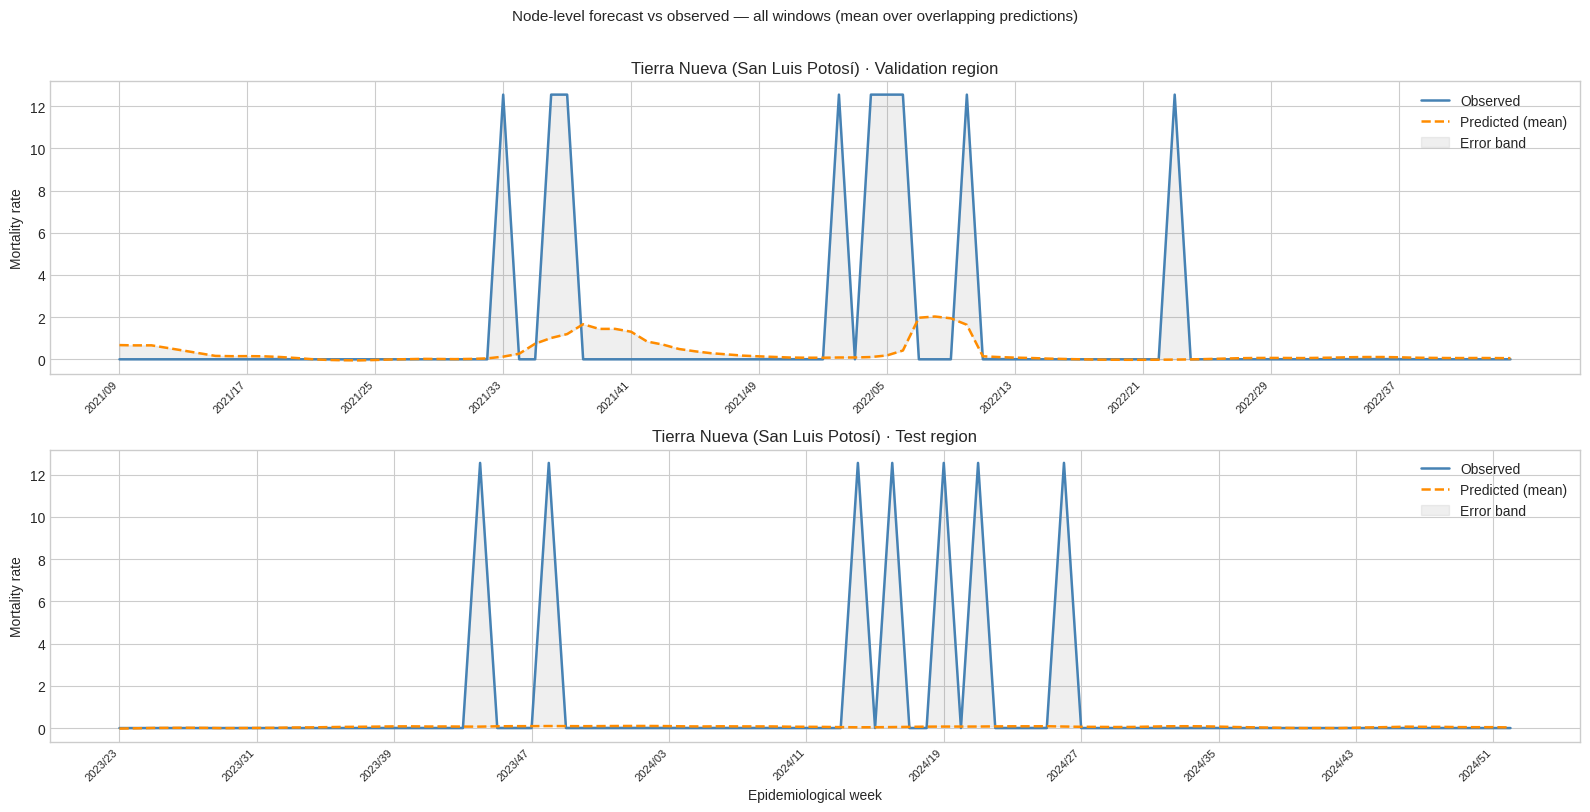

In [14]:
focus_node_idx = example_node
focus_label = (
    f"{node_frame.loc[focus_node_idx, 'municipality']} "
    f"({node_frame.loc[focus_node_idx, 'state']})"
)


def predict_node_over_region(dataset, node_id):
    """
    Run inference on every window in `dataset` and collect per-step predictions
    and observations for `node_id`. Returns a DataFrame with columns:
    week_idx, predicted, observed.

    When STRIDE < HORIZON_WEEKS multiple windows predict the same week;
    the caller should group-by week_idx and average.
    """
    rows = []
    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]
            b = Batch.from_data_list([sample]).to(device)
            pred = model(b)
            pred_orig = restore_scale(pred).cpu()
            tgt_orig = restore_scale(b.y).cpu()
            t0 = int(sample.window_start.item()) + WINDOW_WEEKS
            for step in range(HORIZON_WEEKS):
                rows.append(
                    {
                        "week_idx": t0 + step,
                        "predicted": pred_orig[node_id, step].item(),
                        "observed": tgt_orig[node_id, step].item(),
                    }
                )
    return pd.DataFrame(rows)


print(f"Collecting predictions for: {focus_label}")
print("  · validation region …")
val_preds_df = predict_node_over_region(val_dataset, focus_node_idx)
print("  · test region …")
test_preds_df = predict_node_over_region(test_dataset, focus_node_idx)

# Average predictions that fall on the same week (overlapping windows)
val_agg = val_preds_df.groupby("week_idx")[["predicted", "observed"]].mean().reset_index()
test_agg = test_preds_df.groupby("week_idx")[["predicted", "observed"]].mean().reset_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

tick_step = 8  # one x-tick label every 8 weeks

for ax, agg_df, title_suffix in [
    (axes[0], val_agg, "Validation region"),
    (axes[1], test_agg, "Test region"),
]:
    xs = agg_df["week_idx"].values
    obs = agg_df["observed"].values
    prd = agg_df["predicted"].values

    ax.plot(xs, obs, linewidth=1.8, color="steelblue", label="Observed")
    ax.plot(xs, prd, linewidth=1.8, color="darkorange", linestyle="--", label="Predicted (mean)")
    ax.fill_between(xs, obs, prd, alpha=0.12, color="gray", label="Error band")

    tick_pos = xs[::tick_step]
    tick_lbl = [str(week_labels[i]) for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{focus_label} · {title_suffix}")
    ax.set_ylabel("Mortality rate")
    ax.legend(loc="upper right")

axes[1].set_xlabel("Epidemiological week")
plt.suptitle(
    "Node-level forecast vs observed — all windows (mean over overlapping predictions)",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()


## 12 · Useful extensions

- Increase `WINDOW_WEEKS` to give the model more historical context.
- Increase `HORIZON_WEEKS` to predict farther ahead.
- Add exogenous environmental variables as extra node features per time step.
- Swap `GCNConv` for `SAGEConv`, `GATConv`, or a custom message-passing block.
- Increase `num_backtest_origins` or use a denser rolling step to stress-test temporal robustness.